C:\Users\nguye\AppData\Local\Temp\ipykernel_17464\3560894124.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


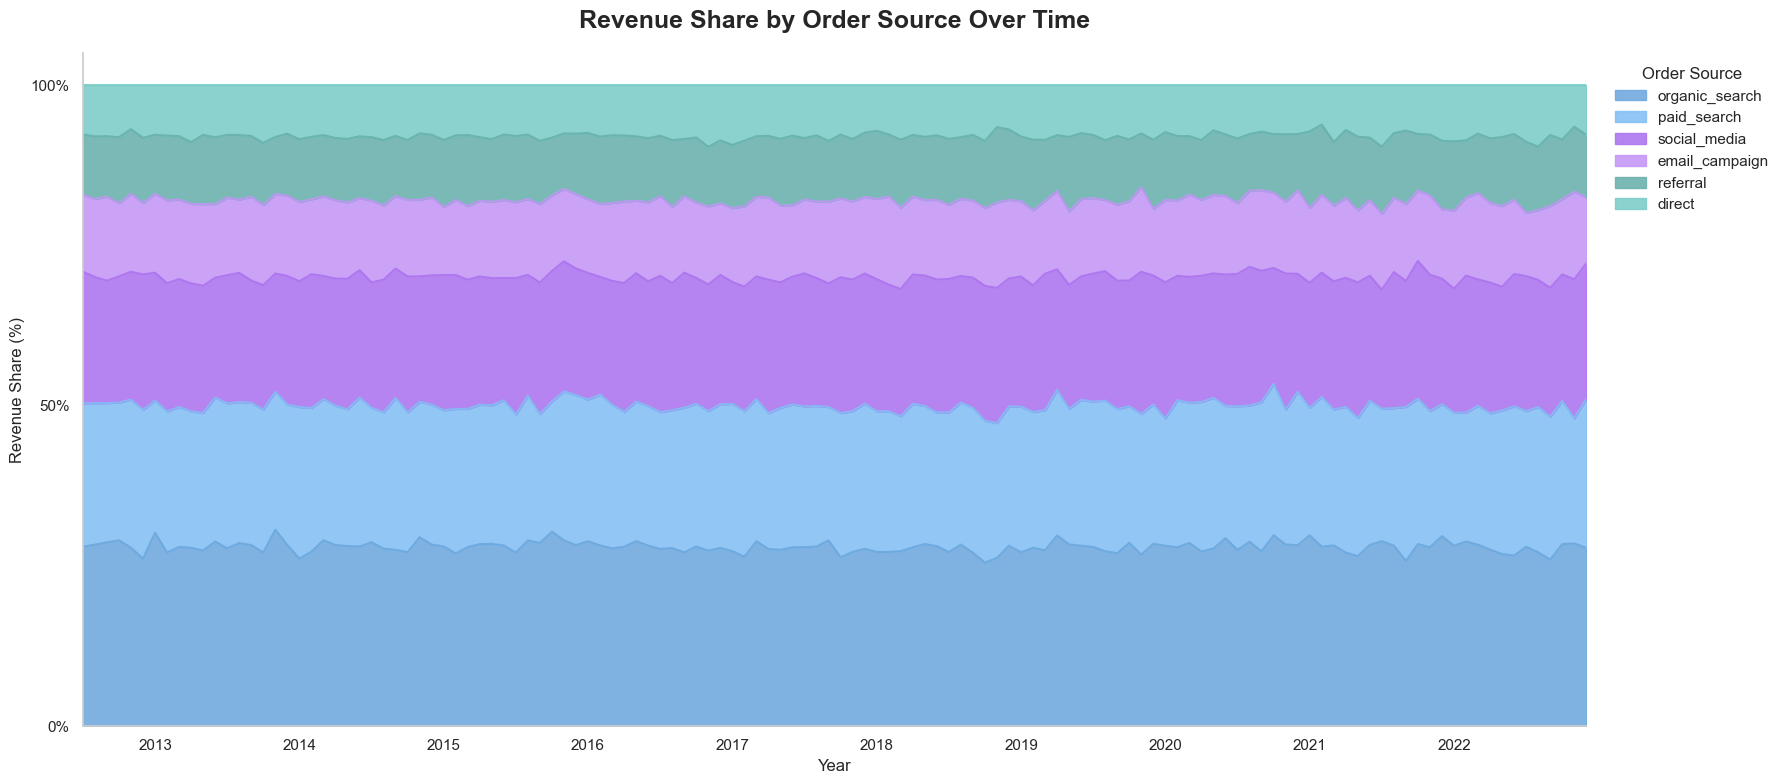

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv("../data/order_items.csv")

# Compute revenue
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["discount_amount"]
)

# Merge order source
df = order_items.merge(
    orders[["order_id", "order_date", "order_source"]],
    on="order_id",
    how="left"
)

# Aggregate by month and order source
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = (
    df.groupby(["month", "order_source"])["revenue"]
    .sum()
    .reset_index()
)

# Pivot table
pivot = monthly_revenue.pivot(
    index="month",
    columns="order_source",
    values="revenue"
).fillna(0)

# Sort sources by total revenue
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

# Convert revenue to revenue share
pivot_share = pivot.div(pivot.sum(axis=1), axis=0)

# Colors
colors = [
    "#6DA8DD",
    "#82BFF4",
    "#AC73EE",
    "#C396F7",
    "#68B0AC",
    "#7BCCC8",
]

assert len(colors) == pivot_share.shape[1], "Số màu không khớp với số lượng order_source"

# Export data to CSV
pivot_share.reset_index().to_csv(
    "../data/revenue_share_by_order_source.csv",
    index=False
)

# Plot
fig, ax = plt.subplots(figsize=(18, 8))

pivot_share.plot.area(
    ax=ax,
    alpha=0.88,
    color=colors
)

ax.set_title(
    "Revenue Share by Order Source Over Time",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Year")
ax.set_ylabel("Revenue Share (%)")

# Y-axis: 0%, 50%, 100%
ax.set_yticks([0, 0.5, 1])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# X-axis: chỉ hiển thị năm
year_ticks = pivot_share.index[pivot_share.index.month == 1]

ax.set_xticks(year_ticks)
ax.set_xticklabels(
    [d.strftime("%Y") for d in year_ticks],
    rotation=0
)

ax.legend(
    title="Order Source",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

pivot_share.to_csv("db4-data/revenue_share_by_order_source.csv")

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\nguye\AppData\Local\Temp\ipykernel_19184\942819088.py:21: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([traffic_ts, orders_ts], axis=1)


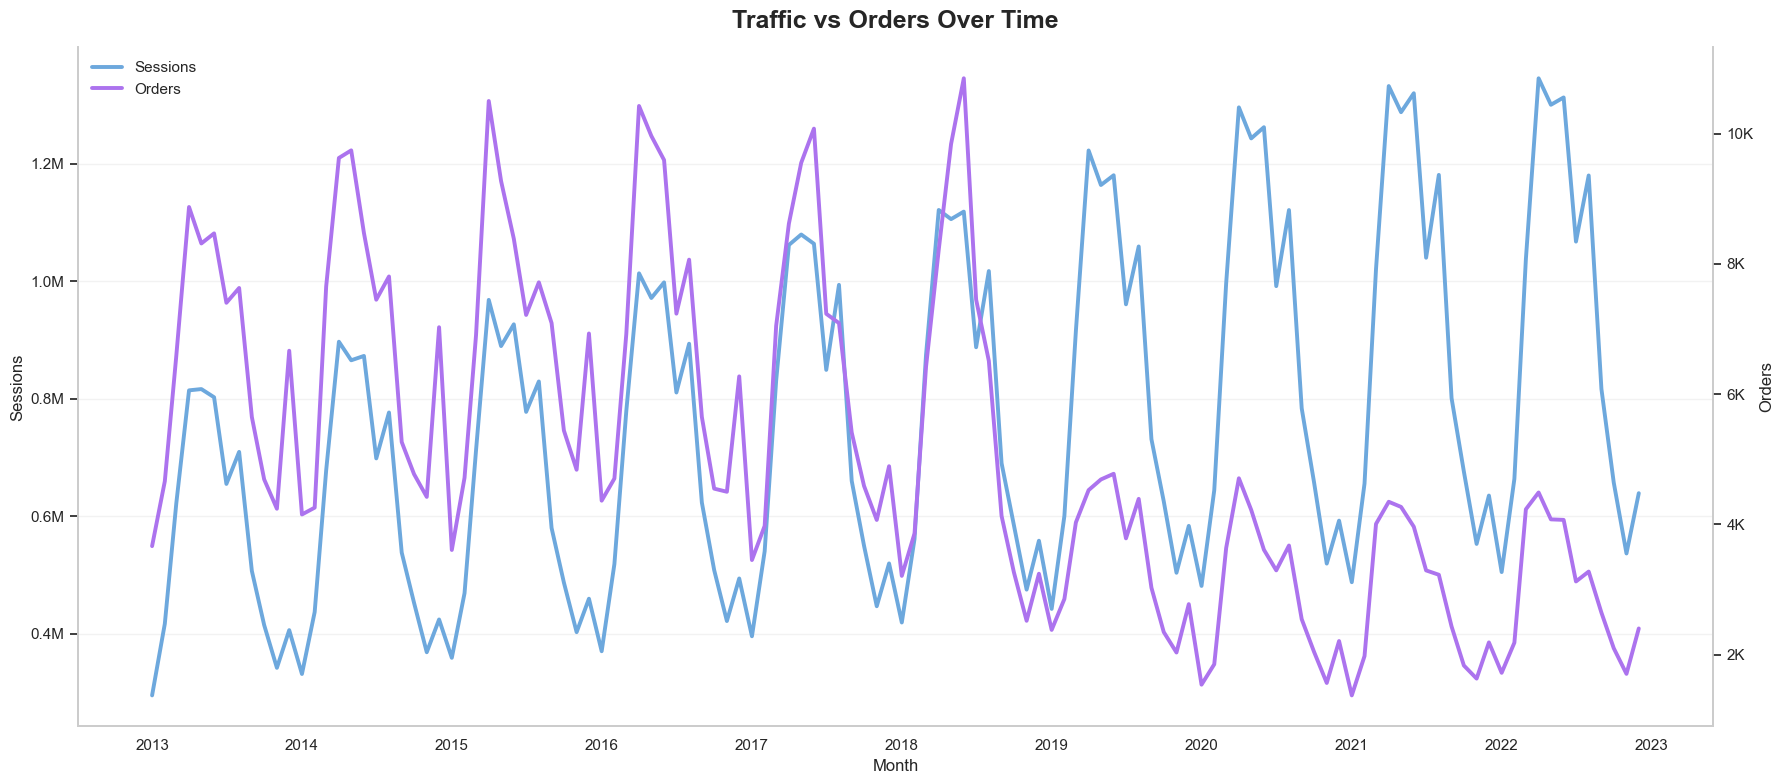

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# Load data
traffic = pd.read_csv("../data/web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])

# Monthly traffic
traffic["month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
traffic_ts = traffic.groupby("month")["sessions"].sum()

# Monthly orders
orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()
orders_ts = orders.groupby("month")["order_id"].nunique()

# Combine
df = pd.concat([traffic_ts, orders_ts], axis=1)
df.columns = ["sessions", "orders"]
df = df.dropna()

# Plot dual-axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Left axis: Sessions
ax1.plot(
    df.index,
    df["sessions"],
    color="#6DA8DD",
    linewidth=2.8,
    label="Sessions"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sessions")
ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

# Right axis: Orders
ax2 = ax1.twinx()

ax2.plot(
    df.index,
    df["orders"],
    color="#AC73EE",
    linewidth=2.8,
    label="Orders"
)

ax2.set_ylabel("Orders")
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

# Title
ax1.set_title(
    "Traffic vs Orders Over Time",
    fontsize=18,
    fontweight="bold",
    pad=14
)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# Style
ax1.grid(axis="y", alpha=0.25)
ax1.grid(axis="x", visible=False)
ax2.grid(False)

sns.despine(right=False)

plt.tight_layout()
plt.show()

df.to_csv("db4-data/traffic_orders_monthly.csv", index=True)

C:\Users\nguye\AppData\Local\Temp\ipykernel_22796\1491183639.py:12: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


,order_source,revenue_lift,conversion_lift,aov_effect,cr_promo,cr_no_promo,rps_promo,rps_no_promo,aov_promo,aov_no_promo
1,email_campaign,-0.385068,-0.094452,-0.320928,0.002718,0.003002,51.898418,84.397046,19093.303632,28116.772528
2,organic_search,-0.387484,-0.100663,-0.318925,0.003037,0.003377,57.434528,93.768228,18912.419207,27768.486361
3,paid_search,-0.391733,-0.106424,-0.319290,0.003323,0.003719,63.140667,103.804248,19000.112297,27912.184372
4,referral,-0.391957,-0.108843,-0.317693,0.002934,0.003293,55.822592,91.807005,19023.408432,27880.993056
0,direct,-0.392695,-0.129533,-0.302323,0.003055,0.003509,58.819939,96.854068,19254.288919,27597.717617
5,social_media,-0.406519,-0.112808,-0.331057,0.003653,0.004118,68.631084,115.641531,18786.583990,28083.977911


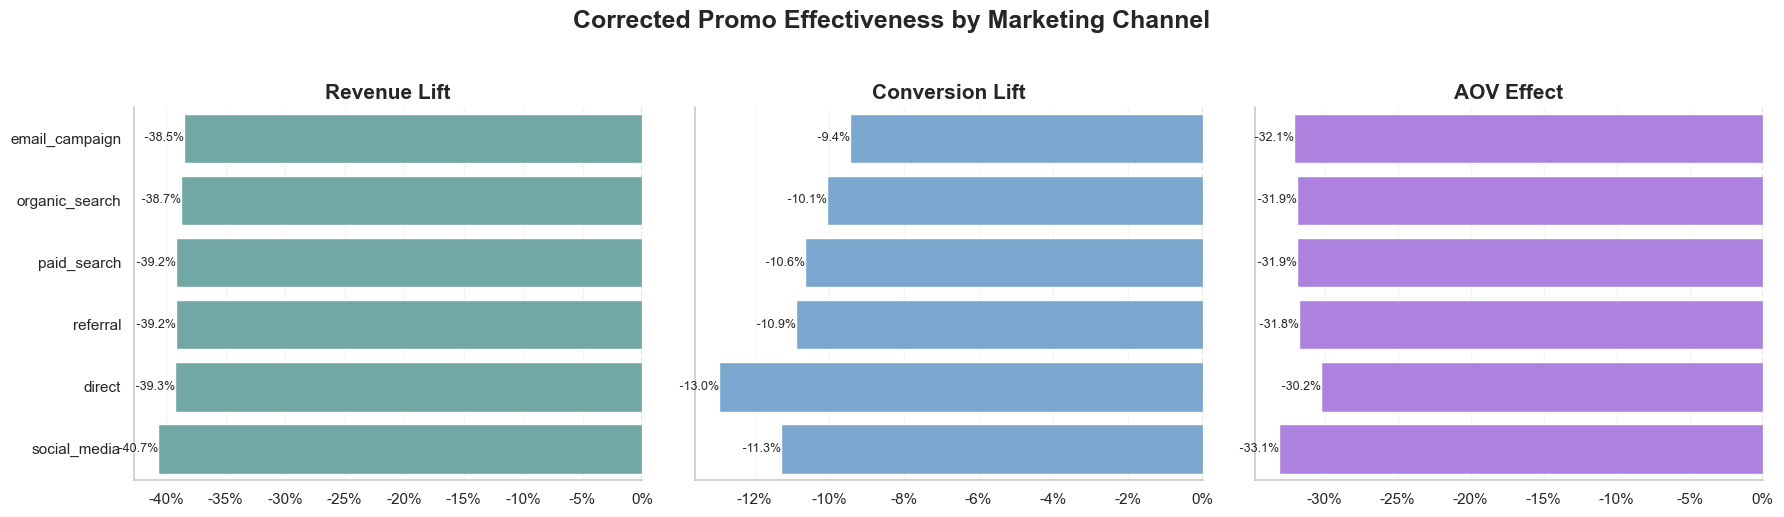

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv("../data/order_items.csv")
traffic = pd.read_csv("../data/web_traffic.csv")

# =========================
# 2. COMPUTE REVENUE
# =========================
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["discount_amount"]
)

# Revenue per order
order_revenue = (
    order_items.groupby("order_id")["revenue"]
    .sum()
    .reset_index()
)

# =========================
# 3. PROMO FLAG PER ORDER
# =========================
promo_flag = (
    order_items.assign(has_promo=lambda x: x["promo_id"].notna())
    .groupby("order_id")["has_promo"]
    .max()
    .reset_index()
)

promo_flag["promo_group"] = promo_flag["has_promo"].map({
    True: "Promo",
    False: "No Promo"
})

# =========================
# 4. MERGE BASE TABLE
# =========================
df = orders.merge(order_revenue, on="order_id", how="left")
df = df.merge(promo_flag[["order_id", "promo_group"]], on="order_id", how="left")

df["promo_group"] = df["promo_group"].fillna("No Promo")

# =========================
# 5. MONTHLY TIME MATCHING
# =========================
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

traffic["month"] = pd.to_datetime(traffic["date"]).dt.to_period("M").dt.to_timestamp()

traffic_seg = (
    traffic.groupby(["traffic_source", "month"])["sessions"]
    .sum()
    .reset_index()
)

# =========================
# 6. AGGREGATE BY CHANNEL + MONTH + PROMO
# =========================
monthly = (
    df.groupby(["order_source", "month", "promo_group"])
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

monthly = monthly.merge(
    traffic_seg,
    left_on=["order_source", "month"],
    right_on=["traffic_source", "month"],
    how="left"
)

monthly = monthly.dropna(subset=["sessions"])

# =========================
# 7. KEEP ONLY MATCHED CHANNEL-MONTHS
#    Có cả Promo và No Promo trong cùng channel + month
# =========================
matched_months = (
    monthly.groupby(["order_source", "month"])["promo_group"]
    .nunique()
    .reset_index()
)

matched_months = matched_months[matched_months["promo_group"] == 2][
    ["order_source", "month"]
]

monthly_matched = monthly.merge(
    matched_months,
    on=["order_source", "month"],
    how="inner"
)

# =========================
# 8. CORRECT AGGREGATION
#    Aggregate first, then divide
# =========================
correct = (
    monthly_matched.groupby(["order_source", "promo_group"])
    .agg(
        total_orders=("orders", "sum"),
        total_revenue=("revenue", "sum"),
        total_sessions=("sessions", "sum")
    )
    .reset_index()
)

# Pivot
pivot = correct.pivot(
    index="order_source",
    columns="promo_group",
    values=["total_orders", "total_revenue", "total_sessions"]
)

# Flatten columns
pivot.columns = [f"{metric}_{promo}" for metric, promo in pivot.columns]
pivot = pivot.reset_index()

# Keep only channels có đủ Promo và No Promo
required_cols = [
    "total_orders_Promo",
    "total_orders_No Promo",
    "total_revenue_Promo",
    "total_revenue_No Promo",
    "total_sessions_Promo",
    "total_sessions_No Promo"
]

pivot = pivot.dropna(subset=required_cols)

# =========================
# 9. COMPUTE CORRECT METRICS
# =========================

# Conversion Rate
pivot["cr_promo"] = pivot["total_orders_Promo"] / pivot["total_sessions_Promo"]
pivot["cr_no_promo"] = pivot["total_orders_No Promo"] / pivot["total_sessions_No Promo"]

pivot["conversion_lift"] = (
    (pivot["cr_promo"] - pivot["cr_no_promo"])
    / pivot["cr_no_promo"]
)

# Revenue per Session
pivot["rps_promo"] = pivot["total_revenue_Promo"] / pivot["total_sessions_Promo"]
pivot["rps_no_promo"] = pivot["total_revenue_No Promo"] / pivot["total_sessions_No Promo"]

pivot["revenue_lift"] = (
    (pivot["rps_promo"] - pivot["rps_no_promo"])
    / pivot["rps_no_promo"]
)

# AOV
pivot["aov_promo"] = pivot["total_revenue_Promo"] / pivot["total_orders_Promo"]
pivot["aov_no_promo"] = pivot["total_revenue_No Promo"] / pivot["total_orders_No Promo"]

pivot["aov_effect"] = (
    (pivot["aov_promo"] - pivot["aov_no_promo"])
    / pivot["aov_no_promo"]
)

# =========================
# 10. FINAL METRICS TABLE
# =========================
metrics_df = pivot[[
    "order_source",
    "revenue_lift",
    "conversion_lift",
    "aov_effect",
    "cr_promo",
    "cr_no_promo",
    "rps_promo",
    "rps_no_promo",
    "aov_promo",
    "aov_no_promo"
]].copy()

metrics_df = metrics_df.sort_values("revenue_lift", ascending=False)

display(metrics_df)

# =========================
# 11. VISUALIZATION: 3 SMALL CHARTS
# =========================
metrics = {
    "revenue_lift": "Revenue Lift",
    "conversion_lift": "Conversion Lift",
    "aov_effect": "AOV Effect"
}

colors = {
    "revenue_lift": "#68B0AC",
    "conversion_lift": "#6DA8DD",
    "aov_effect": "#AC73EE"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (col, title) in zip(axes, metrics.items()):
    sns.barplot(
        data=metrics_df,
        x=col,
        y="order_source",
        ax=ax,
        color=colors[col]
    )

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f"{x:.0%}")
    )

    for i, v in enumerate(metrics_df[col]):
        ax.text(
            v,
            i,
            f" {v:.1%}" if v >= 0 else f" {v:.1%}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=9
        )

    ax.grid(axis="x", alpha=0.2)
    ax.grid(axis="y", visible=False)

fig.suptitle(
    "Corrected Promo Effectiveness by Marketing Channel",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()
plt.show()

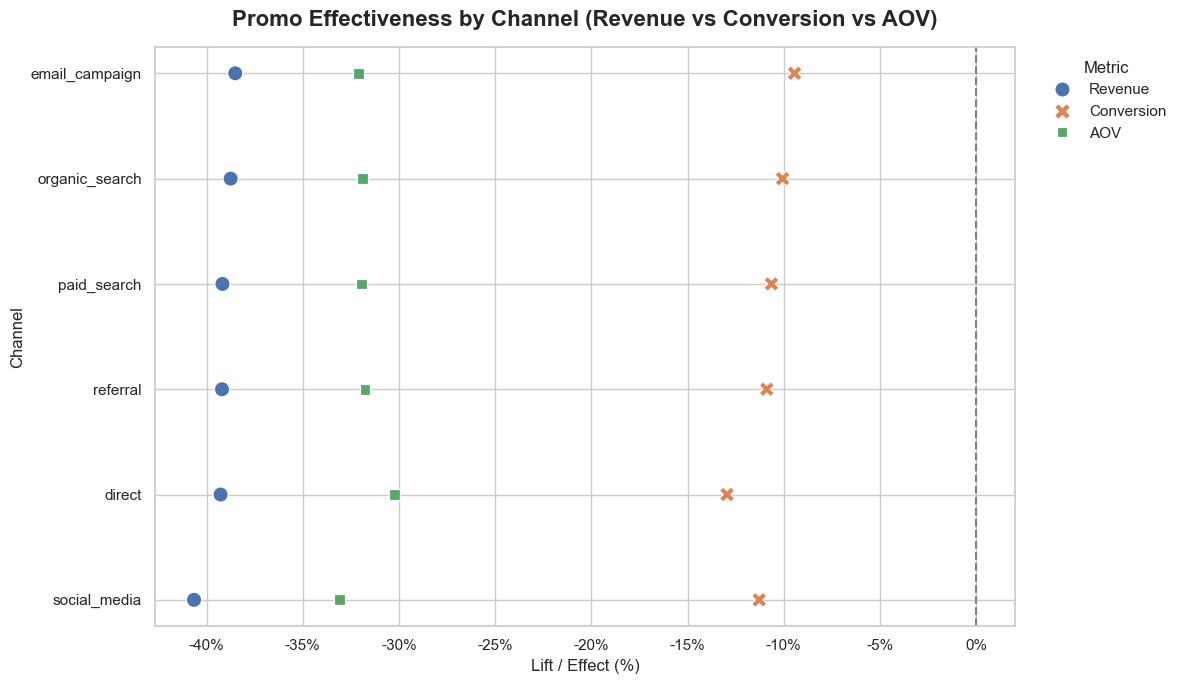

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# reshape data
# =========================
plot_df = metrics_df.melt(
    id_vars="order_source",
    value_vars=["revenue_lift", "conversion_lift", "aov_effect"],
    var_name="metric",
    value_name="value"
)

metric_map = {
    "revenue_lift": "Revenue",
    "conversion_lift": "Conversion",
    "aov_effect": "AOV"
}

plot_df["metric"] = plot_df["metric"].map(metric_map)

# =========================
# plot
# =========================
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=plot_df,
    x="value",
    y="order_source",
    hue="metric",
    style="metric",
    s=120
)

# zero line
plt.axvline(0, linestyle="--", color="gray")

# format
plt.title(
    "Promo Effectiveness by Channel (Revenue vs Conversion vs AOV)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Lift / Effect (%)")
plt.ylabel("Channel")

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_22796\2776071189.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


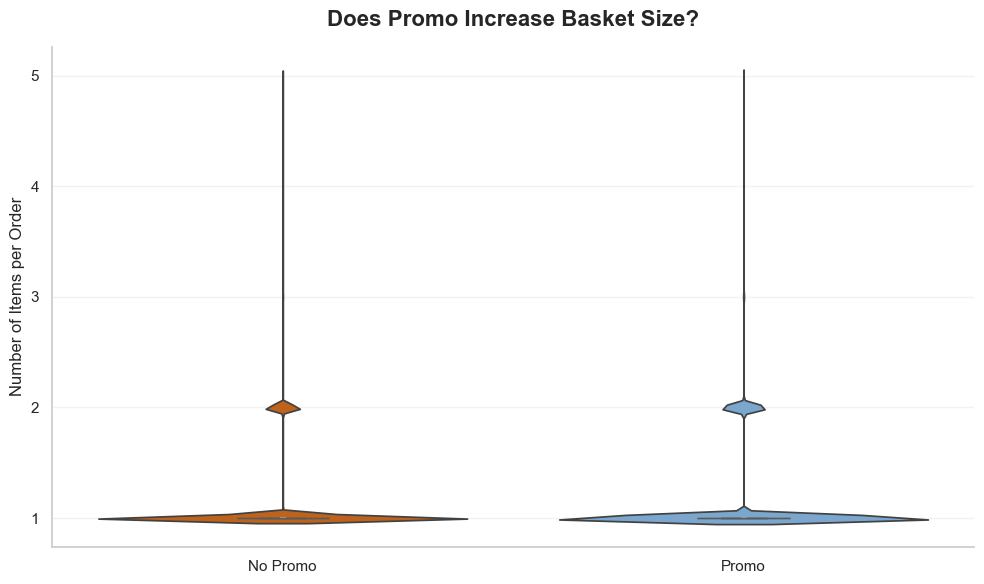

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =========================
# Prepare data
# =========================

# Count items per order
items_per_order = (
    order_items.groupby("order_id")["product_id"]
    .nunique()
    .reset_index(name="items_per_order")
)

# Promo flag
promo_flag = (
    order_items.groupby("order_id")[["promo_id", "promo_id_2"]]
    .apply(lambda x: x.notna().any().any())
    .reset_index(name="is_promo")
)

# Merge
df = items_per_order.merge(promo_flag, on="order_id")

df["promo_group"] = df["is_promo"].map({
    True: "Promo",
    False: "No Promo"
})

# =========================
# Plot
# =========================
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="promo_group",
    y="items_per_order",
    palette=["#D95F02", "#6DA8DD"]
)

sns.boxplot(
    data=df,
    x="promo_group",
    y="items_per_order",
    width=0.2,
    showcaps=True,
    boxprops={'facecolor':'white'},
    showfliers=False
)

plt.title(
    "Does Promo Increase Basket Size?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("")
plt.ylabel("Number of Items per Order")

plt.grid(axis="y", alpha=0.25)
sns.despine()

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import plotly.graph_objects as go

# =========================
# Prepare order-level promo flag
# =========================
orders_df = orders.copy()
items_df = order_items.copy()

orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

promo_cols = [c for c in ["promo_id", "promo_id_2"] if c in items_df.columns]

if "discount_amount" in items_df.columns:
    items_df["has_discount"] = items_df["discount_amount"].fillna(0) > 0
else:
    items_df["has_discount"] = False

items_df["has_promo_id"] = False
for col in promo_cols:
    items_df["has_promo_id"] = items_df["has_promo_id"] | items_df[col].notna()

items_df["is_promo_item"] = items_df["has_promo_id"] | items_df["has_discount"]

order_promo = (
    items_df.groupby("order_id")["is_promo_item"]
    .any()
    .reset_index(name="is_promo_order")
)

df = orders_df.merge(order_promo, on="order_id", how="left")
df["is_promo_order"] = df["is_promo_order"].fillna(False)

# =========================
# Customer purchase sequence
# =========================
df = df.sort_values(["customer_id", "order_date", "order_id"])

df["purchase_no"] = (
    df.groupby("customer_id")
    .cumcount() + 1
)

df = df[df["purchase_no"].isin([1, 2, 3])]

df["stage_label"] = df.apply(
    lambda x: f"Purchase {x['purchase_no']}: " + ("Promo" if x["is_promo_order"] else "No Promo"),
    axis=1
)

seq = (
    df.pivot_table(
        index="customer_id",
        columns="purchase_no",
        values="stage_label",
        aggfunc="first"
    )
    .reset_index()
)

seq = seq.rename(columns={
    1: "purchase_1",
    2: "purchase_2",
    3: "purchase_3"
})

seq["purchase_2"] = seq["purchase_2"].fillna("No 2nd Purchase")
seq["purchase_3"] = seq["purchase_3"].fillna("No 3rd Purchase")

# =========================
# Build Sankey links
# =========================
links_12 = (
    seq.groupby(["purchase_1", "purchase_2"])
    .size()
    .reset_index(name="value")
)

links_23 = (
    seq.groupby(["purchase_2", "purchase_3"])
    .size()
    .reset_index(name="value")
)

links = pd.concat([
    links_12.rename(columns={"purchase_1": "source", "purchase_2": "target"}),
    links_23.rename(columns={"purchase_2": "source", "purchase_3": "target"})
])

labels = pd.unique(links[["source", "target"]].values.ravel()).tolist()
label_to_id = {label: i for i, label in enumerate(labels)}

links["source_id"] = links["source"].map(label_to_id)
links["target_id"] = links["target"].map(label_to_id)

# =========================
# Color logic
# =========================
node_colors = []
for label in labels:
    if "Promo" in label:
        node_colors.append("#B22222")
    elif "No Promo" in label:
        node_colors.append("#4C78A8")
    else:
        node_colors.append("#9E9E9E")

link_colors = []
for _, row in links.iterrows():
    if "Promo" in row["source"] and "Promo" in row["target"]:
        link_colors.append("rgba(178,34,34,0.35)")
    elif "Promo" in row["source"] and "No" in row["target"]:
        link_colors.append("rgba(178,34,34,0.18)")
    elif "No Promo" in row["source"] and "Promo" in row["target"]:
        link_colors.append("rgba(76,120,168,0.20)")
    else:
        link_colors.append("rgba(120,120,120,0.18)")

# =========================
# Plot
# =========================
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=25,
        thickness=22,
        line=dict(color="white", width=1),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=links["source_id"],
        target=links["target_id"],
        value=links["value"],
        color=link_colors
    )
)])

fig.update_layout(
    title=dict(
        text="<b>Does Promo Create Customer Addiction?</b><br><sup>Customer purchase path from 1st → 2nd → 3rd order</sup>",
        font=dict(size=22)
    ),
    font=dict(size=13),
    height=700,
    width=1100
)

fig.show()